<a href="https://colab.research.google.com/github/SusanaSernaJaramillo/Data-Integration_2.0/blob/main/Reto_Parcial_2_Susana_Serna_J.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caso de estudio: Gestión prospectiva de fallas tecnológicas y captura de GEI**

Una entidad del sector FINTECH quiere implementar un sistema de gestión prospectiva de riesgos basado en el potencial de captura de Gases de Efecto Invernadero (GEI).
El objetivo es identificar, clasificar y cuantificar pérdidas asociadas a fallas tecnológicas, para estimar cómo diferentes niveles de gestión prospectiva reducen el riesgo y aumentan la captura de valor y GEI.

La metodología consiste en:

Cargar y limpiar la base de datos de fallas tecnológicas.
Calcular pérdidas inherentes asociadas a cada evento.
Clusterizar los eventos según frecuencia, severidad e impacto usando K-Means.
Generar matrices de riesgo (frecuencia y pérdidas agregadas).
Aplicar niveles de gestión prospectiva para calcular pérdidas residuales y valor capturado.
Estimación de captura de GEI como indicador financiero de sostenibilidad.
Calcular indicadores adicionales como pérdida esperada y OpVaR 99,9% por nivel de gestión.

Este notebook está construido paso a paso como caso de estudio, con explicación de cada bloque de código y visualizaciones de los resultados, permitiendo entender el impacto de la gestión prospectiva en la reducción de pérdidas y la captura de GEI.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Primero cargamos la base de datos desde Excel, revisamos sus columnas y visualizamos los primeros registros. Esto nos permite entender la estructura y las variables disponibles para nuestro análisis.

In [17]:
# Ruta del archivo en Google Drive
nxlo = '/content/drive/MyDrive/Integración de datos/Bases de datos/5. Riesgo Operacional FallasTecnológicas.xlsx'

# Lectura de las hojas
fallas = pd.read_excel(nxlo, sheet_name='Fallas Tecnológicas', header=1)
tabla_riesgos = pd.read_excel(nxlo, sheet_name='Riesgos', header=1)
tabla_gestion = pd.read_excel(nxlo, sheet_name='Gestión', header=1)

# Copiar la base para trabajar
eventos_tecnologicos = fallas.copy()

# Revisar primeras filas y columnas
eventos_tecnologicos.head()
print("Columnas disponibles:")
print(eventos_tecnologicos.columns)
eventos_tecnologicos.head()

Columnas disponibles:
Index(['Fechas', 'Transacciones Diarias', 'Valor Transado (millones)',
       'Transacciones Fallidas', 'Valor Generado Promedio (Millones)',
       'Descripción Evento'],
      dtype='object')


,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


Limpieza y preparación de datos:

In [18]:
# Eliminar filas vacías
eventos_tecnologicos = eventos_tecnologicos.dropna()

# Columnas numéricas
cols_numericas = ['Transacciones Diarias', 'Valor Transado (millones)',
                  'Transacciones Fallidas', 'Valor Generado Promedio (Millones)']

for col in cols_numericas:
    eventos_tecnologicos[col] = pd.to_numeric(eventos_tecnologicos[col], errors='coerce')

# Convertir fechas
eventos_tecnologicos['Fechas'] = pd.to_datetime(eventos_tecnologicos['Fechas'])

# Revisar info final
eventos_tecnologicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Fechas                              701 non-null    datetime64[ns]
 1   Transacciones Diarias               701 non-null    int64         
 2   Valor Transado (millones)           701 non-null    float64       
 3   Transacciones Fallidas              701 non-null    int64         
 4   Valor Generado Promedio (Millones)  701 non-null    float64       
 5   Descripción Evento                  701 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 33.0+ KB


Eliminamos filas vacías, aseguramos que las columnas numéricas sean realmente numéricas y convertimos la columna de fechas al tipo correcto. Esto garantiza que los cálculos posteriores sean precisos.

Calculamos la pérdida financiera por cada evento sin aplicar gestión. Esto nos da la línea base de riesgo.

In [19]:
eventos_tecnologicos['Perdida_LDA'] = eventos_tecnologicos['Transacciones Fallidas'] * eventos_tecnologicos['Valor Generado Promedio (Millones)']

eventos_tecnologicos[['Fechas','Transacciones Fallidas','Valor Generado Promedio (Millones)','Perdida_LDA']].head()

,Fechas,Transacciones Fallidas,Valor Generado Promedio (Millones),Perdida_LDA
0,2009-01-01,1,0.5374,0.5374
1,2009-01-02,4,1.1978,4.7912
2,2009-01-03,5,0.4269,2.1345
3,2009-01-04,6,1.0814,6.4884
4,2009-01-05,7,1.2105,8.4735


Clasificamos cada evento en niveles 1–5 según frecuencia, severidad e impacto, de manera que podamos construir matrices de riesgo claras y visuales.

In [20]:
# Limpiar posibles NaN en las columnas a clusterizar
eventos_tecnologicos = eventos_tecnologicos.dropna(subset=['Transacciones Fallidas',
                                                           'Valor Generado Promedio (Millones)',
                                                           'Perdida_LDA'])

# Función corregida
def cluster_kmeans_5niveles(df, columna, nombre_nueva_col):
    X = df[[columna]].values
    modelo = KMeans(n_clusters=5, random_state=0, n_init=10)
    clusters = modelo.fit_predict(X)

    # Ordenar clusters de menor a mayor
    centros = modelo.cluster_centers_.flatten()
    orden = np.argsort(centros)
    mapa_niveles = {cluster: i+1 for i, cluster in enumerate(orden)}

    # Crear columna directamente en el DataFrame
    df[nombre_nueva_col] = [mapa_niveles[c] for c in clusters]
    return df

# Aplicar clusterización
eventos_tecnologicos = cluster_kmeans_5niveles(eventos_tecnologicos, 'Transacciones Fallidas', 'Nivel_Frecuencia')
eventos_tecnologicos = cluster_kmeans_5niveles(eventos_tecnologicos, 'Valor Generado Promedio (Millones)', 'Nivel_Severidad')
eventos_tecnologicos = cluster_kmeans_5niveles(eventos_tecnologicos, 'Perdida_LDA', 'Nivel_Impacto')

# Revisar columnas nuevas
eventos_tecnologicos[['Nivel_Frecuencia','Nivel_Severidad','Nivel_Impacto']].head()

,Nivel_Frecuencia,Nivel_Severidad,Nivel_Impacto
0,1,1,1
1,2,2,1
2,3,1,1
3,3,1,2
4,4,2,2


La metodología K-Means permitió clasificar los eventos en niveles de riesgo del 1 al 5 según:

Frecuencia de eventos.
Severidad financiera.
Impacto total de pérdida.

Los primeros resultados muestran que los eventos fueron distribuidos correctamente en diferentes niveles, permitiendo segmentar riesgos bajos, medios y altos.

La clusterización facilita visualizar cuáles eventos representan una mayor exposición operacional para la entidad FINTECH

Visualizamos la distribución de eventos según frecuencia y severidad, y también las pérdidas agregadas. Esto nos permite identificar los puntos críticos de riesgo.

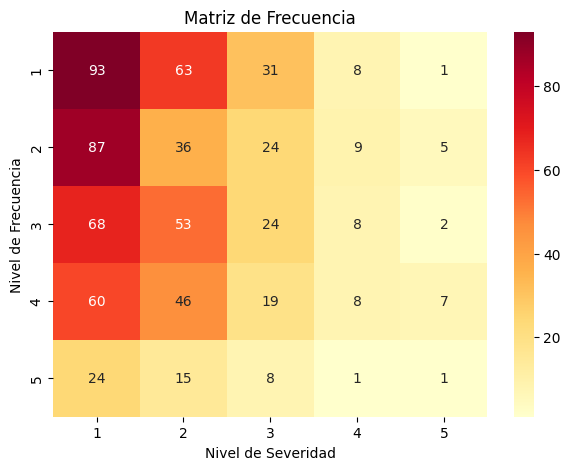

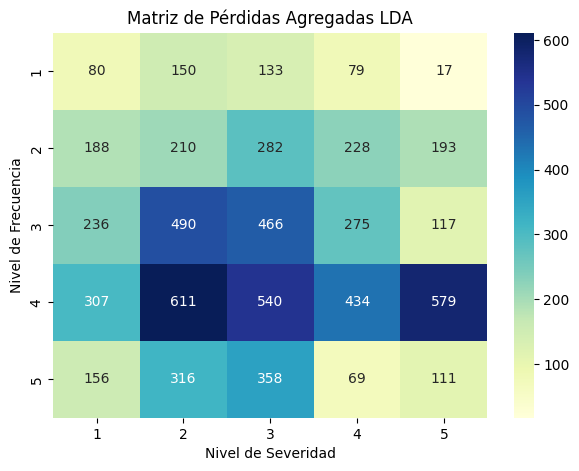

In [21]:
# Matriz de frecuencia
matriz_frecuencia = pd.crosstab(eventos_tecnologicos['Nivel_Frecuencia'], eventos_tecnologicos['Nivel_Severidad'])
plt.figure(figsize=(7,5))
sns.heatmap(matriz_frecuencia, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Matriz de Frecuencia')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Nivel de Frecuencia')
plt.show()

# Matriz de pérdidas agregadas
matriz_perdidas = eventos_tecnologicos.pivot_table(values='Perdida_LDA',
                                                   index='Nivel_Frecuencia',
                                                   columns='Nivel_Severidad',
                                                   aggfunc='sum',
                                                   fill_value=0)
plt.figure(figsize=(7,5))
sns.heatmap(matriz_perdidas, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Matriz de Pérdidas Agregadas LDA')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Nivel de Frecuencia')
plt.show()

La matriz de frecuencia evidencia que la mayor concentración de eventos se encuentra en los niveles bajos y medios de severidad.

Por ejemplo:

La combinación Frecuencia 1 – Severidad 1 presenta 93 eventos.
La combinación Frecuencia 2 – Severidad 1 presenta 87 eventos.
Las combinaciones de severidad alta tienen menor cantidad de eventos.

Esto indica que las fallas tecnológicas ocurren con relativa frecuencia, pero la mayoría generan impactos moderados o bajos.

Sin embargo, aunque los eventos críticos son menos frecuentes, siguen representando riesgos importantes para la operación.

La matriz de pérdidas agregadas muestra que los mayores valores financieros se concentran en combinaciones medias y altas de frecuencia y severidad.

Algunos resultados importantes fueron:

Frecuencia 4 – Severidad 2: pérdida agregada de 611.
Frecuencia 4 – Severidad 3: pérdida agregada de 540.
Frecuencia 4 – Severidad 5: pérdida agregada de 579.

Esto demuestra que ciertos eventos tecnológicos, aunque no sean los más frecuentes, generan pérdidas económicas significativamente mayores.

La matriz permite identificar las zonas críticas donde la entidad debería priorizar controles y estrategias de mitigación.

Calculamos las pérdidas residuales y el valor capturado según el nivel de gestión, usando un índice de efectividad académico.

In [22]:
# Preparar tabla de gestión
tabla_gestion = pd.read_excel(nxlo, sheet_name='Gestión', header=1)
tabla_gestion = tabla_gestion.dropna()
tabla_gestion = tabla_gestion.rename(columns={tabla_gestion.columns[0]: 'Nivel', tabla_gestion.columns[1]: 'Nombre_Gestion'})
tabla_gestion = tabla_gestion[['Nivel','Nombre_Gestion','Actividades de Gestión','Costo (KUSD)','Desviación']]
tabla_gestion['Efectividad'] = tabla_gestion['Nivel']/5  # Suposición académica

factor_gei = 1
perdida_total = eventos_tecnologicos['Perdida_LDA'].sum()

resultados = []
for i in range(len(tabla_gestion)):
    nivel = int(tabla_gestion.iloc[i]['Nivel'])
    nombre = tabla_gestion.iloc[i]['Nombre_Gestion']
    efectividad = tabla_gestion.iloc[i]['Efectividad']
    costo = tabla_gestion.iloc[i]['Costo (KUSD)']

    perdida_residual = perdida_total * (1 - efectividad)
    valor_capturado = perdida_total - perdida_residual
    captura_gei = valor_capturado * factor_gei
    porcentaje_captura = (valor_capturado / perdida_total) * 100

    resultados.append([nivel,nombre,efectividad,costo,perdida_total,perdida_residual,
                       valor_capturado,captura_gei,porcentaje_captura])

resultado_gestion = pd.DataFrame(resultados, columns=['Nivel de Gestión','Nombre Gestión','Efectividad',
                                                       'Costo (KUSD)','Pérdida Inherente Total',
                                                       'Pérdida Residual Total','Valor Capturado Financiero',
                                                       'Captura GEI Estimada','% Captura GEI'])
resultado_gestion

,Nivel de Gestión,Nombre Gestión,Efectividad,Costo (KUSD),Pérdida Inherente Total,Pérdida Residual Total,Valor Capturado Financiero,Captura GEI Estimada,% Captura GEI
0,1,Bajo,0.2,0.012171,6625.23,5300.184,1325.046,1325.046,20.0
1,2,Medio,0.4,0.037437,6625.23,3975.138,2650.092,2650.092,40.0
2,3,Moderado,0.6,0.173067,6625.23,2650.092,3975.138,3975.138,60.0
3,4,Alto,0.8,0.407991,6625.23,1325.046,5300.184,5300.184,80.0
4,5,Crítico,1.0,0.628350,6625.23,0.000,6625.230,6625.230,100.0


/tmp/ipykernel_1037/2087178952.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultado_gestion, x='Nombre Gestión', y='Captura GEI Estimada', palette='viridis')


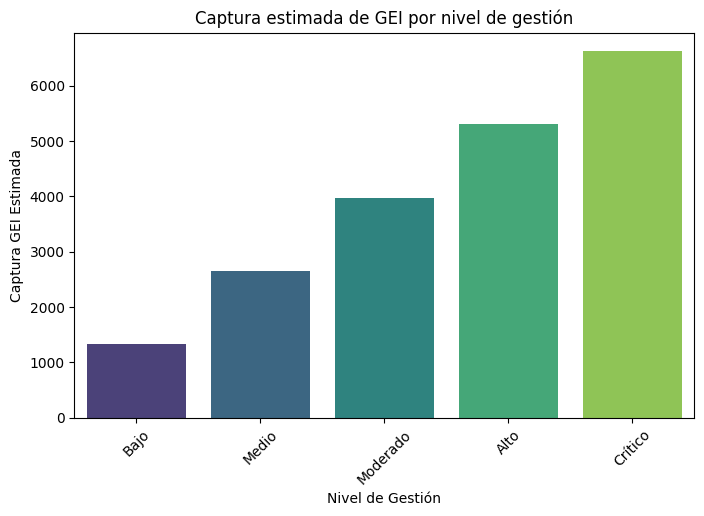

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(data=resultado_gestion, x='Nombre Gestión', y='Captura GEI Estimada', palette='viridis')
plt.title('Captura estimada de GEI por nivel de gestión')
plt.xlabel('Nivel de Gestión')
plt.ylabel('Captura GEI Estimada')
plt.xticks(rotation=45)
plt.show()

Análisis de la gestión prospectiva y captura de GEI

Los resultados muestran que, a medida que aumenta el nivel de gestión prospectiva, disminuye la pérdida residual y aumenta el valor capturado financiero.

Por ejemplo:

Nivel Bajo:
Captura GEI estimada: 1325.046
Captura del 20%
Nivel Moderado:
Captura GEI estimada: 3975.138
Captura del 60%
Nivel Crítico:
Captura GEI estimada: 6625.230
Captura del 100%

Esto evidencia que una gestión prospectiva más fuerte permite reducir significativamente las pérdidas derivadas de fallas tecnológicas.

Adicionalmente, el valor capturado financiero se utiliza como un indicador aproximado de captura de GEI, mostrando cómo la reducción del riesgo también puede interpretarse desde una perspectiva de sostenibilidad.

El gráfico de captura estimada de GEI muestra una tendencia creciente conforme aumenta el nivel de gestión.

Se observa que:

Los niveles bajos generan poca captura.
Los niveles altos y críticos generan una captura considerablemente mayor.

Esto confirma que la efectividad de la gestión prospectiva tiene una relación directa con la reducción del riesgo operacional.

In [24]:
indicadores = []
for i in range(len(tabla_gestion)):
    nivel = int(tabla_gestion.iloc[i]['Nivel'])
    nombre = tabla_gestion.iloc[i]['Nombre_Gestion']
    efectividad = tabla_gestion.iloc[i]['Efectividad']

    perdida_residual_evento = eventos_tecnologicos['Perdida_LDA']*(1-efectividad)
    perdida_esperada = perdida_residual_evento.mean()
    opvar = np.percentile(perdida_residual_evento,99.9)

    indicadores.append([nivel,nombre,perdida_esperada,opvar])

indicadores_riesgo = pd.DataFrame(indicadores, columns=['Nivel de Gestión','Nombre Gestión','Pérdida Esperada','OpVaR 99.9%'])
indicadores_riesgo

,Nivel de Gestión,Nombre Gestión,Pérdida Esperada,OpVaR 99.9%
0,1,Bajo,7.560890,82.32168
1,2,Medio,5.670668,61.74126
2,3,Moderado,3.780445,41.16084
3,4,Alto,1.890223,20.58042
4,5,Crítico,0.000000,0.00000


Los indicadores adicionales muestran una reducción progresiva tanto de la pérdida esperada como del OpVaR 99.9%. Esto significa que:

Los niveles altos de gestión reducen el riesgo promedio.
También disminuyen las pérdidas extremas bajo escenarios críticos.

El OpVaR permite estimar escenarios de pérdida severa y es útil para fortalecer la toma de decisiones y controles operacionales.

Permite consultar los eventos que pertenecen a una combinación específica de frecuencia y severidad, para auditar los riesgos críticos.

**FILTRO DE AUDITORIA**

In [25]:
frecuencia_elegida = int(input("Ingrese el nivel de frecuencia a consultar (1-5): "))
severidad_elegida = int(input("Ingrese el nivel de severidad a consultar (1-5): "))

eventos_filtrados = eventos_tecnologicos[
    (eventos_tecnologicos["Nivel_Frecuencia"] == frecuencia_elegida) &
    (eventos_tecnologicos["Nivel_Severidad"] == severidad_elegida)
]

print("\nCantidad de eventos encontrados:", len(eventos_filtrados))
if len(eventos_filtrados) > 0:
    print("\nEventos asociados a la celda seleccionada:")
    display(eventos_filtrados)
else:
    print("\nNo se encontraron eventos para esa combinación de frecuencia y severidad.")

Ingrese el nivel de frecuencia a consultar (1-5): 3
Ingrese el nivel de severidad a consultar (1-5): 3

Cantidad de eventos encontrados: 24

Eventos asociados a la celda seleccionada:


,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento,Perdida_LDA,Nivel_Frecuencia,Nivel_Severidad,Nivel_Impacto
55,2009-02-25,100,34.6232,6,4.1309,"Degradación del rendimiento por varias horas, ...",24.7854,3,3,3
221,2009-08-10,90,24.5724,6,2.8662,"Degradación del rendimiento por varias horas, ...",17.1972,3,3,3
248,2009-09-06,130,16.8640,5,3.7633,"Degradación del rendimiento por varias horas, ...",18.8165,3,3,3
255,2009-09-13,115,36.4969,6,2.8320,"Degradación del rendimiento por varias horas, ...",16.9920,3,3,3
273,2009-10-01,115,20.9718,5,2.7295,"Degradación del rendimiento por varias horas, ...",13.6475,3,3,2
282,2009-10-10,75,18.0117,6,3.6744,"Degradación del rendimiento por varias horas, ...",22.0464,3,3,3
292,2009-10-20,65,17.9698,5,4.3713,"Degradación del rendimiento por varias horas, ...",21.8565,3,3,3
293,2009-10-21,95,29.8914,5,3.3977,"Degradación del rendimiento por varias horas, ...",16.9885,3,3,3
398,2011-02-18,75,32.5414,6,3.0696,"Degradación del rendimiento por varias horas, ...",18.4176,3,3,3
420,2011-03-12,75,41.5171,6,3.0000,"Degradación del rendimiento por varias horas, ...",18.0000,3,3,3


El filtro de auditoría permitió identificar eventos específicos asociados a determinadas combinaciones de frecuencia y severidad.

Por ejemplo, para la combinación:

Frecuencia = 3
Severidad = 3

Se encontraron 24 eventos relacionados principalmente con:

“Degradación del rendimiento por varias horas”

Esto facilita identificar cuáles eventos generan mayor impacto y permite priorizar acciones de mejora tecnológica y controles preventivos.

**CONCLUSIÓN GENERAL**

A partir del desarrollo del modelo de gestión prospectiva se concluye que:

La clusterización K-Means permitió clasificar adecuadamente los eventos tecnológicos según su nivel de riesgo.
Las matrices de frecuencia y pérdidas ayudaron a identificar zonas críticas de exposición operacional.
La gestión prospectiva reduce significativamente las pérdidas residuales.
El valor capturado financiero aumenta conforme mejora la gestión.
La captura estimada de GEI puede interpretarse como un indicador de sostenibilidad asociado a la reducción del riesgo.

En general, el modelo demuestra que una adecuada gestión prospectiva permite anticipar eventos críticos, disminuir impactos financieros y fortalecer la sostenibilidad operacional de la entidad FINTECH.